In [ ]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 1

import numpy as np
from astropy.io import ascii
import os
import matplotlib.pyplot as plt
from astropy.utils.data import download_file
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.nddata import Cutout2D
from astropy import units as u
from photutils.aperture import aperture_photometry
from photutils.aperture import CircularAperture
from photutils.aperture import CircularAnnulus
from astropy.stats import sigma_clipped_stats

from photutils.psf import fit_fwhm
os.chdir("/Users/dapur")

plate_fits = fits.open('C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\cutouts\00264_a01988m0s0.fits')
plate_fits.info()
image_data = plate_fits[0].data

Filename: C:/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/R_CrB/cutouts/00460_i28786m0s0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      30   (835, 835)   int16   


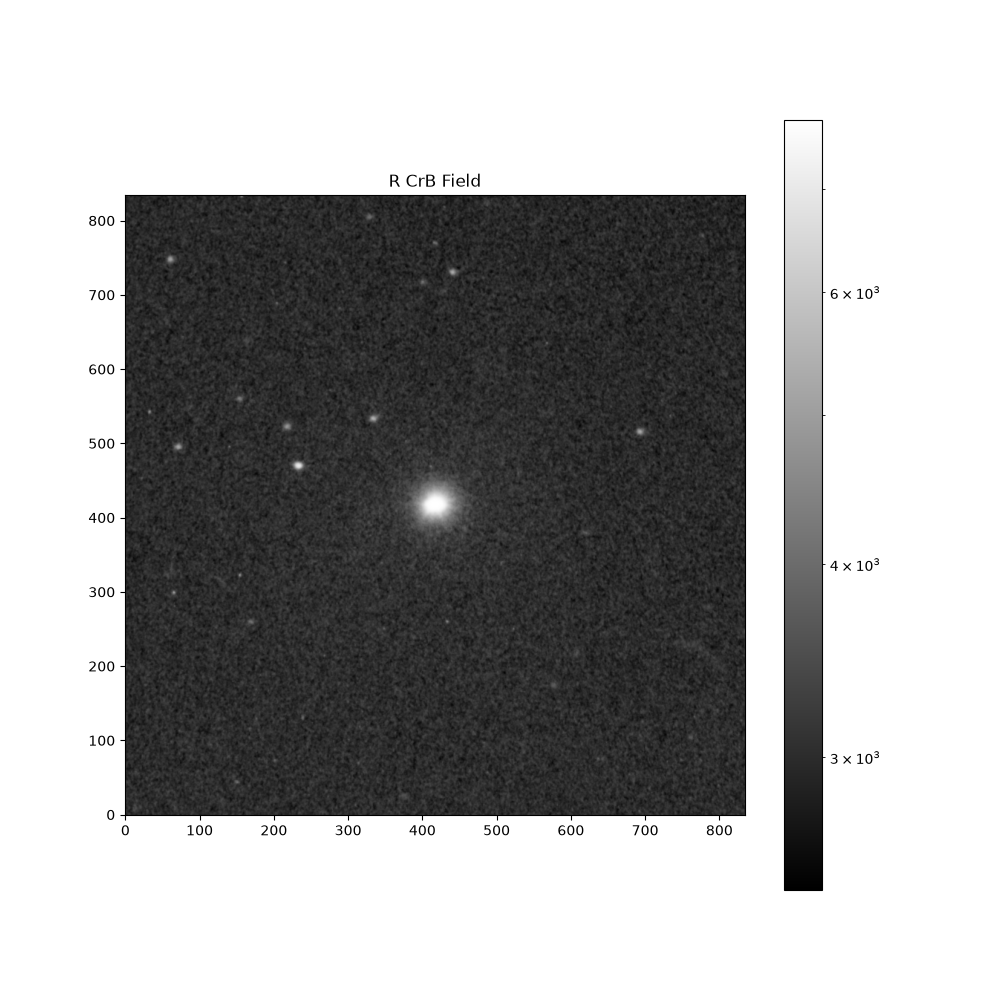

In [3]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 2

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(image_data, origin='lower', cmap='gray', norm=LogNorm())
ax.set_title('R CrB Field')

def format_coord(x, y):
    col = int(x + 0.5)
    row = int(y + 0.5)
    if 0 <= row < image_data.shape[0] and 0 <= col < image_data.shape[1]:
        value = image_data[row, col]
        return f'x={col}, y={row}, value={value:.1f}'
    return f'x={col}, y={row}'

ax.format_coord = format_coord
plt.colorbar(im, ax=ax)
plt.show()

Centroid refinement (original -> refined):
  Star 0: (418.0, 418.0) -> (417.97, 417.98)  shift=(-0.03, -0.02)
  Star 1: (233.0, 471.0) -> (233.00, 470.80)  shift=(+0.00, -0.20)
  Star 2: (440.0, 732.0) -> (440.08, 731.90)  shift=(+0.08, -0.10)
  Star 3: (693.0, 514.0) -> (693.08, 514.17)  shift=(+0.08, +0.17)
  Star 4: (217.0, 524.0) -> (217.09, 523.92)  shift=(+0.09, -0.08)
  Star 5: (70.0, 498.0) -> (70.15, 497.77)  shift=(+0.15, -0.23)

Proximity warning: Star 1 nearest neighbor is 55.4px away -- shrinking aperture 40px -> 25.7px to avoid overlap
Proximity warning: Star 4 nearest neighbor is 55.4px away -- shrinking aperture 40px -> 25.7px to avoid overlap

id  x       y       aper_r    aperture_sum_0    residual_sum
0   418.0   418.0   40.0      23159924.5        6089766.5
1   233.0   470.8   25.7      6703560.6         379884.1
2   440.1   731.9   40.0      15046025.9        127230.9
3   693.1   514.2   40.0      15092305.5        47846.5
4   217.1   523.9   25.7      6373438.3   

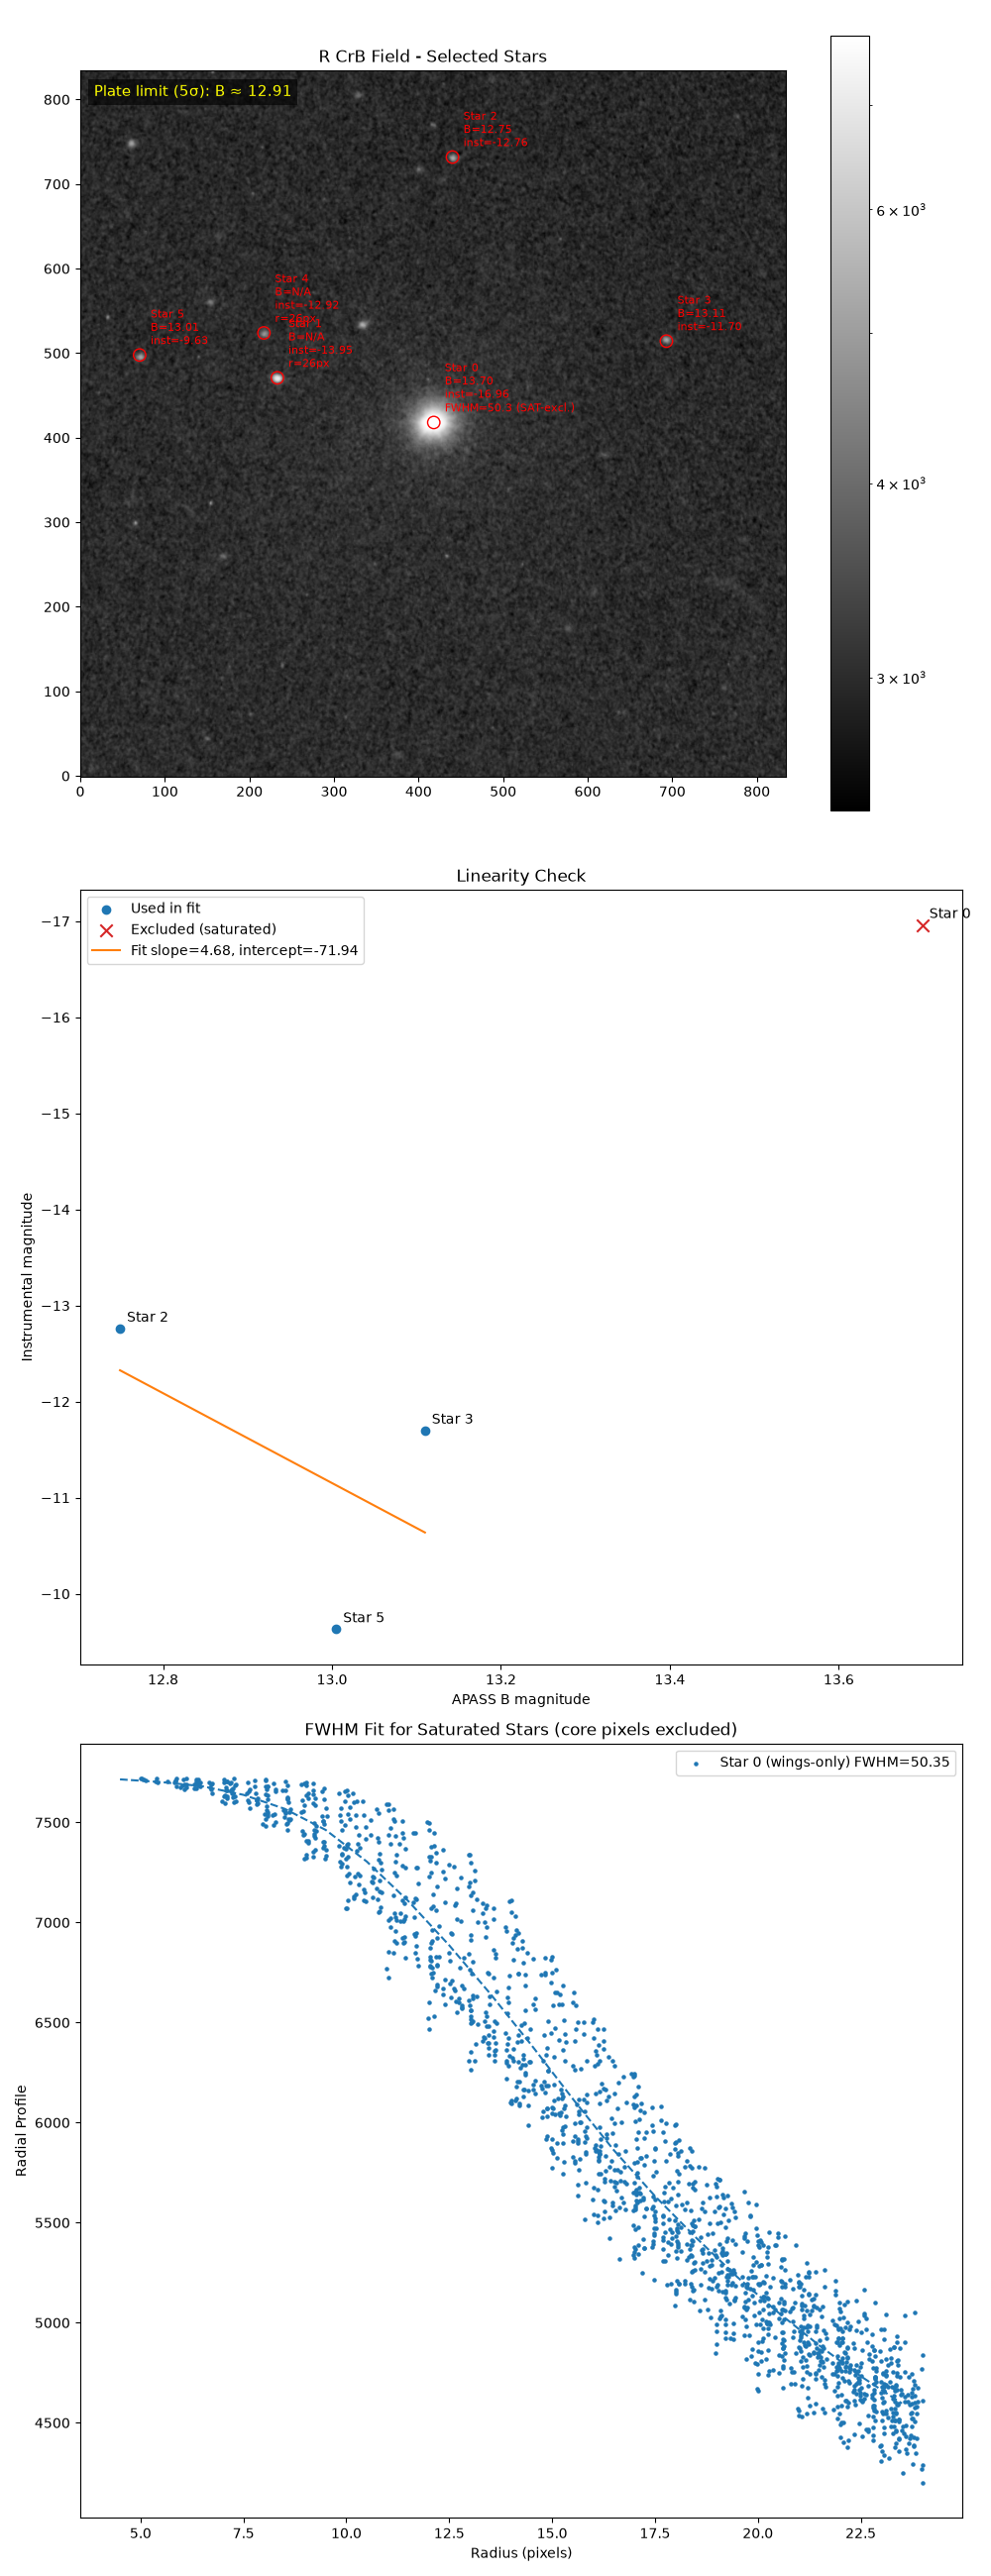


Star 0: residual = -9.077 mag (excluded from fit -- saturated)
Star 1: no APASS match -- residual not applicable
Star 2: residual = -0.435 mag
Star 3: residual = -1.061 mag
Star 4: no APASS match -- residual not applicable
Star 5: residual = 1.497 mag
Using Star 2 as reference (APASS B=12.75, inst=-12.76)

id  derived B (vs Star 2)     APASS B     diff      status
0   8.55                      13.70       -5.15     SATURATED
1   11.56                     N/A         --        
2   12.75                     12.75       +0.00     REF
3   13.81                     13.11       +0.70     
4   12.59                     N/A         --        
5   15.88                     13.01       +2.87     


In [17]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 3

positions = [(418.,418.),(233,471),(440,732),(693,514),(217,524),(70,498)] # Select stars
n_stars = len(positions)

# Refine each star's pixel position via centroiding, instead of trusting the
# hand-picked coordinates exactly. Even a few pixels of miscentering biases
# the flux captured in a fixed-radius aperture. 

from photutils.centroids import centroid_sources, centroid_com

xs_init = np.array([p[0] for p in positions], dtype=float)
ys_init = np.array([p[1] for p in positions], dtype=float)
centroid_box = 21  # pixels; should comfortably contain the star's peak but not a neighbor

xs_refined, ys_refined = centroid_sources(image_data, xs_init, ys_init,
                                           box_size=centroid_box, centroid_func=centroid_com)

print("Centroid refinement (original -> refined):")
for i in range(n_stars):
    dx = xs_refined[i] - xs_init[i]
    dy = ys_refined[i] - ys_init[i]
    flag = "  <-- shifted >3px, check this one" if np.hypot(dx, dy) > 3 else ""
    print(f"  Star {i}: ({xs_init[i]:.1f}, {ys_init[i]:.1f}) -> ({xs_refined[i]:.2f}, {ys_refined[i]:.2f})  shift=({dx:+.2f}, {dy:+.2f}){flag}")
print()

positions = list(zip(xs_refined.tolist(), ys_refined.tolist()))
positions_arr = np.array(positions, dtype=float)

default_r = 40
annulus_width = 5
min_aperture_r = 8      # never shrink an aperture below this, no matter how crowded
safety_buffer = 2       # pixel gap kept between two neighboring apertures

# Adaptive aperture sizing: shrink a star's aperture only if a neighbor is close
# enough that default r=40 apertures would physically overlap and contaminate
# each other's flux. Uncrowded stars keep the full r=40 aperture.

min_sep = np.full(n_stars, np.inf)
for i in range(n_stars):
    for j in range(n_stars):
        if i == j:
            continue
        d = np.hypot(positions_arr[i,0]-positions_arr[j,0], positions_arr[i,1]-positions_arr[j,1])
        min_sep[i] = min(min_sep[i], d)

aper_radii = np.array([min(default_r, sep/2 - safety_buffer) for sep in min_sep])
aper_radii = np.clip(aper_radii, min_aperture_r, default_r)

for i in range(n_stars):
    if min_sep[i] < 2 * default_r:
        note = f" -- shrinking aperture {default_r}px -> {aper_radii[i]:.1f}px to avoid overlap" if aper_radii[i] < default_r else ""
        print(f"Proximity warning: Star {i} nearest neighbor is {min_sep[i]:.1f}px away{note}")
print()

apertures = [CircularAperture(positions[i], r=aper_radii[i]) for i in range(n_stars)]
annuli = [CircularAnnulus(positions[i], r_in=aper_radii[i], r_out=aper_radii[i]+annulus_width) for i in range(n_stars)]

# Full-image mask marking every pixel that falls inside ANY star's aperture. Used to
# strip neighboring stars' light out of each star's local background annulus, even
# if the annuli themselves happen to reach into a neighbor's territory.
combined_star_mask = np.zeros(image_data.shape, dtype=bool)
for ap in apertures:
    ap_image = ap.to_mask(method='center').to_image(image_data.shape)
    if ap_image is not None:
        combined_star_mask |= (ap_image > 0)

aperture_sum_0 = np.zeros(n_stars)
final_sum2 = np.zeros(n_stars)
bkg_std_values = np.zeros(n_stars)

for i in range(n_stars):  # Background subtraction
    t = aperture_photometry(image_data, apertures[i])
    aperture_sum_0[i] = t['aperture_sum'][0]

    ann_mask = annuli[i].to_mask(method='center')
    ann_full = ann_mask.to_image(image_data.shape)
    footprint_full = ann_full > 0
    clean_footprint_full = footprint_full & (~combined_star_mask)  # exclude neighbor stars

    ann_data_1d = image_data[clean_footprint_full]
    _, median_sigclip, std_sigclip = sigma_clipped_stats(ann_data_1d)
    bkg_mean2 = median_sigclip
    bkg_sum2 = bkg_mean2 * apertures[i].area
    final_sum2[i] = aperture_sum_0[i] - bkg_sum2
    bkg_std_values[i] = std_sigclip

print(f"{'id':<4}{'x':<8}{'y':<8}{'aper_r':<10}{'aperture_sum_0':<18}{'residual_sum'}")
for i in range(n_stars):
    print(f"{i:<4}{positions[i][0]:<8.1f}{positions[i][1]:<8.1f}{aper_radii[i]:<10.1f}{aperture_sum_0[i]:<18.1f}{final_sum2[i]:.1f}")
print()

instrumental_mag = -2.5 * np.log10(final_sum2)

m0m1 = -2.5*np.log10(final_sum2[0]/final_sum2[1])
m1m2 = -2.5*np.log10(final_sum2[1]/final_sum2[2])
m0m2 = -2.5*np.log10(final_sum2[0]/final_sum2[2])
print(m0m1, m1m2, m0m2)
print()

# Query APASS DR9 (via Vizier ASU-TSV) for B magnitudes at each star's RA/Dec.
# Retries with a wider search radius and prints the raw response if the first
# attempt finds nothing, instead of silently giving up.

import urllib.request
import urllib.parse
from astropy.wcs import WCS
from photutils.profiles import RadialProfile

wcs = WCS(plate_fits[0].header)

def query_apass_raw(ra, dec, radius_arcsec):
    params = {
        '-source': 'II/336/apass9',
        '-c': f'{ra} {dec}',
        '-c.rs': radius_arcsec,
        '-out': 'Bmag,e_Bmag',
        '-out.max': 5,
    }
    url = 'https://vizier.cds.unistra.fr/viz-bin/asu-tsv?' + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=15) as response:
        return response.read().decode('utf-8')

def parse_bmag(raw_text):
    for line in raw_text.splitlines():
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-') or line.startswith('Bmag'):
            continue
        parts = line.split('\t')
        if len(parts) >= 1:
            try:
                return float(parts[0])
            except ValueError:
                continue
    return np.nan

apass_B_mag = []

for i, (x, y) in enumerate(positions):
    ra, dec = wcs.all_pix2world(x, y, 0)
    ra, dec = float(ra), float(dec)

    raw = query_apass_raw(ra, dec, radius_arcsec=10)
    bmag = parse_bmag(raw)

    if np.isnan(bmag):
        # First attempt found nothing -- retry with a wider search before giving up.
        raw_wide = query_apass_raw(ra, dec, radius_arcsec=20)
        bmag = parse_bmag(raw_wide)
        if np.isnan(bmag):
            print(f"Star {i}: no APASS match within 20 arcsec of RA={ra:.5f}, Dec={dec:.5f}")
            print("  Raw Vizier response:")
            for line in raw_wide.splitlines():
                print("    " + line)
        else:
            print(f"Star {i}: RA={ra:.5f}, Dec={dec:.5f} -> Bmag={bmag:.3f} (found only at 20arcsec)")
    else:
        print(f"Star {i}: RA={ra:.5f}, Dec={dec:.5f} -> Bmag={bmag:.3f}")

    apass_B_mag.append(bmag)

apass_B_mag = np.array(apass_B_mag)
print(apass_B_mag)

# Saturation check for each star (using its own, possibly shrunk, aperture);
# FWHM only computed for saturated stars

edge_radii = np.arange(25)

is_saturated = np.zeros(n_stars, dtype=bool)
fwhm_values = np.full(n_stars, np.nan)
fwhm_profiles = {}

print(f"Overall image max value: {image_data.max()}")
print(f"Overall image min value: {image_data.min()}")
print()

for i, (x, y) in enumerate(positions):
    aperture_mask = apertures[i].to_mask(method='center')
    aperture_data = aperture_mask.multiply(image_data)
    star_pixels = aperture_data[aperture_mask.data > 0]

    max_val = star_pixels.max()
    near_max_count = np.sum(star_pixels >= max_val * 0.995)
    saturated = near_max_count > 5
    is_saturated[i] = saturated

    print(f"Star {i} at ({x:.1f}, {y:.1f}):")
    print(f"  Max pixel value: {max_val}")
    print(f"  Number of pixels within 0.5% of max: {near_max_count}")
    print(f"  Saturated: {saturated}")

    if saturated:
        xycen = (x, y)
        sat_threshold = max_val * 0.995
        sat_mask = image_data >= sat_threshold
        rp_masked = RadialProfile(image_data, xycen, edge_radii, mask=sat_mask)
        rp_masked.gaussian_fit
        fwhm_values[i] = rp_masked.gaussian_fwhm
        fwhm_profiles[i] = rp_masked
        print(f"  Wings-only FWHM: {fwhm_values[i]:.2f} px (approximate -- saturated core excluded)")
    print()

# Plate display, linearity check (saturated stars excluded from the fit),
# plate limit, and FWHM diagnostic

saturated_indices = [i for i in range(n_stars) if is_saturated[i]]
n_rows = 3 if saturated_indices else 2
fig_height = 26 if saturated_indices else 18

fig, axes = plt.subplots(n_rows, 1, figsize=(10, fig_height))
ax_plate, ax_lin = axes[0], axes[1]

im = ax_plate.imshow(image_data, origin='lower', cmap='gray', norm=LogNorm())
ax_plate.set_title('R CrB Field - Selected Stars')

xs = [p[0] for p in positions]
ys = [p[1] for p in positions]
ax_plate.scatter(xs, ys, s=80, facecolors='none', edgecolors='red')

for i, (x, y) in enumerate(positions):
    bmag_str = f"{apass_B_mag[i]:.2f}" if not np.isnan(apass_B_mag[i]) else "N/A"
    label = f"Star {i}\nB={bmag_str}\ninst={instrumental_mag[i]:.2f}"
    if aper_radii[i] < default_r:
        label += f"\nr={aper_radii[i]:.0f}px"
    if is_saturated[i]:
        label += f"\nFWHM={fwhm_values[i]:.1f} (SAT-excl.)"
    ax_plate.annotate(label, (x, y), color='red', fontsize=8,
                       textcoords="offset points", xytext=(8, 8))

fig.colorbar(im, ax=ax_plate)

# Linearity fit -- excludes any star flagged as saturated (unreliable flux),
# still plots them so the exclusion is visible rather than hidden.
excluded = is_saturated.copy()
valid = (~np.isnan(apass_B_mag)) & (~excluded)

ax_lin.scatter(apass_B_mag[valid], instrumental_mag[valid], color='C0', label='Used in fit')

excl_plot = (~np.isnan(apass_B_mag)) & excluded
if np.any(excl_plot):
    ax_lin.scatter(apass_B_mag[excl_plot], instrumental_mag[excl_plot], color='C3', marker='x',
                    s=80, label='Excluded (saturated)')

for i in range(n_stars):
    if np.isnan(apass_B_mag[i]):
        continue
    ax_lin.annotate(f'Star {i}', (apass_B_mag[i], instrumental_mag[i]), textcoords="offset points", xytext=(5, 5))

fit = np.polyfit(apass_B_mag[valid], instrumental_mag[valid], 1)
fit_line = np.poly1d(fit)
mag_range = np.linspace(apass_B_mag[valid].min(), apass_B_mag[valid].max(), 100)
ax_lin.plot(mag_range, fit_line(mag_range), color='C1', label=f'Fit slope={fit[0]:.2f}, intercept={fit[1]:.2f}')

ax_lin.set_xlabel('APASS B magnitude')
ax_lin.set_ylabel('Instrumental magnitude')
ax_lin.invert_yaxis()
ax_lin.legend()
ax_lin.set_title('Linearity Check')

# Plate limit (5-sigma), using the standard r=40 aperture as the reference area,
# independent of any per-star shrinking done above.
n_sigma = 5
mean_bkg_std = np.nanmean(bkg_std_values)
reference_area = np.pi * default_r**2
threshold_flux = n_sigma * mean_bkg_std * np.sqrt(reference_area)
threshold_inst_mag = -2.5 * np.log10(threshold_flux)
plate_limit_mag = (threshold_inst_mag - fit[1]) / fit[0]

print(f"Mean background noise (sigma): {mean_bkg_std:.2f} counts")
print(f"5-sigma detection threshold flux: {threshold_flux:.1f} counts")
print(f"Estimated plate limit (5-sigma): B ~ {plate_limit_mag:.2f} mag")

ax_plate.text(0.02, 0.98, f'Plate limit (5σ): B ≈ {plate_limit_mag:.2f}',
              transform=ax_plate.transAxes, color='yellow', fontsize=11,
              verticalalignment='top', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

if saturated_indices:
    ax_fwhm = axes[2]
    colors = plt.cm.tab10(np.linspace(0, 1, len(saturated_indices)))
    for idx, i in enumerate(saturated_indices):
        rp = fwhm_profiles[i]
        c = colors[idx]
        ax_fwhm.scatter(rp.data_radius, rp.data_profile, s=5, color=c,
                         label=f'Star {i} (wings-only) FWHM={fwhm_values[i]:.2f}')
        ax_fwhm.plot(rp.radius, rp.profile, color=c, linestyle='--')
    ax_fwhm.set_xlabel('Radius (pixels)')
    ax_fwhm.set_ylabel('Radial Profile')
    ax_fwhm.set_title('FWHM Fit for Saturated Stars (core pixels excluded)')
    ax_fwhm.legend()

plt.tight_layout()
plt.show()

print()
for i in range(n_stars):
    if np.isnan(apass_B_mag[i]):
        print(f"Star {i}: no APASS match -- residual not applicable")
    else:
        resid = instrumental_mag[i] - fit_line(apass_B_mag[i])
        tag = " (excluded from fit -- saturated)" if excluded[i] else ""
        print(f"Star {i}: residual = {resid:.3f} mag{tag}")

# Derive each star's B magnitude via direct comparison to a single reference star
# Instead of relying on a noisy multi-point line fit, anchor to one well-behaved,
# unsaturated, APASS-matched star and transfer its magnitude to every other star using
# only the flux ratio between that pair (classic two-star differential photometry).
# This also serves as a sanity check: for stars that DO have an APASS match, comparing
# the derived value against the real catalog value shows exactly how much each star's
# photometry disagrees with expectation.

candidate_refs = [i for i in range(n_stars) if not np.isnan(apass_B_mag[i]) and not is_saturated[i]]

if not candidate_refs:
    print("No valid, unsaturated, APASS-matched reference star available for comparison.")
else:
    # Use the brightest valid star as the reference (highest S/N, most trustworthy anchor).
    ref = candidate_refs[np.argmax(final_sum2[candidate_refs])]
    print(f"Using Star {ref} as reference (APASS B={apass_B_mag[ref]:.2f}, inst={instrumental_mag[ref]:.2f})")
    print()

    derived_B = np.full(n_stars, np.nan)
    for i in range(n_stars):
        if i == ref:
            derived_B[i] = apass_B_mag[ref]
            continue
        # Magnitude offset from the reference, computed directly from the flux ratio
        # between just these two stars -- no line fit involved.
        delta_mag = -2.5 * np.log10(final_sum2[i] / final_sum2[ref])
        derived_B[i] = apass_B_mag[ref] + delta_mag

    print(f"{'id':<4}{'derived B (vs Star ' + str(ref) + ')':<26}{'APASS B':<12}{'diff':<10}{'status'}")
    for i in range(n_stars):
        apass_str = f"{apass_B_mag[i]:.2f}" if not np.isnan(apass_B_mag[i]) else "N/A"
        if not np.isnan(apass_B_mag[i]):
            diff = derived_B[i] - apass_B_mag[i]
            diff_str = f"{diff:+.2f}"
        else:
            diff_str = "--"
        status = "SATURATED" if is_saturated[i] else ("REF" if i == ref else "")
        print(f"{i:<4}{derived_B[i]:<26.2f}{apass_str:<12}{diff_str:<10}{status}")

In [5]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 4

import matplotlib.pyplot as plt
from photutils.datasets import make_noise_image
from photutils.psf import CircularGaussianPRF, make_psf_model_image,fit_fwhm
from photutils.profiles import RadialProfile

psf_model = CircularGaussianPRF(flux=1, fwhm=2.7)
psf_shape = (9, 9)
n_sources = 10
shape = (101, 101)
data, true_params = make_psf_model_image(shape, psf_model, n_sources,
                                         model_shape=psf_shape,
                                         flux=(500, 700),
                                         min_separation=10, seed=0)
noise = make_noise_image(data.shape, mean=0, stddev=1, seed=0)
data += noise
plt.imshow(data, origin='lower')
plt.title('Simulated Data')
plt.colorbar()

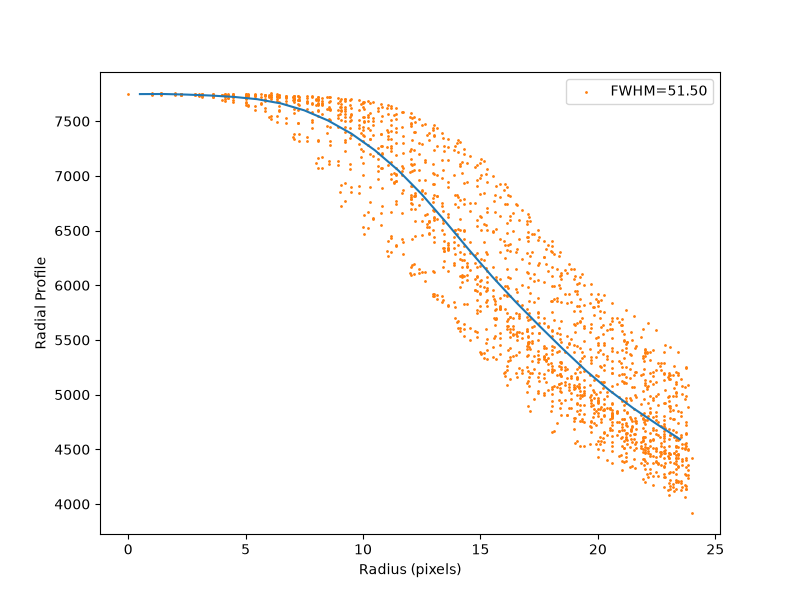

In [6]:
# NOTE : test_Simple_Photometry_Clayton.ipynb - Cell 5

data=image_data
xycen=(416.,416.)
#xycen=(610.,435.)
edge_radii = np.arange(25)
rp = RadialProfile(data, xycen, edge_radii, mask=None)
rp.gaussian_fit
#print(rp.gaussian_fwhm)
fw=str(f"{rp.gaussian_fwhm:.2f}")
fig, ax = plt.subplots(figsize=(8, 6))
rp.plot(ax=ax, color='C0')
#rp.plot_error(ax=ax)
ax.scatter(rp.data_radius, rp.data_profile, s=1, color='C1',label='FWHM='+fw)
#ax.scatter(xx-37,yy)
ax.legend()